# 1 — Registration with reg1d

This notebook reproduces the workflow of `nlreg1d`'s notebook *3-Registration* using `reg1d`:
linear registration by interpolation to a common number of frames, followed by nonlinear
(elastic, SRSF-based) registration.

`reg1d` differs from `nlreg1d` in one important respect: it depends only on **numpy**, **scipy**
and **matplotlib**. The SRSF registration is implemented directly from the mathematics of the
square-root slope framework (Srivastava et al. 2011) rather than by wrapping `fdasrsf`, so
`fdasrsf` and `scikit-fda` do not need to be installed.

The dataset is the `Dorn2012` anteroposterior ground reaction force (GRF) dataset: running at four
speeds (coded 0–3 in increasing order), two trials per speed.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # so that this notebook finds reg1d without installation
import numpy as np
from matplotlib import pyplot as plt
import reg1d
print('reg1d version:', reg1d.__version__)

reg1d version: 0.0.1


### Load data

Dataset: Dorn2012
    J       = 8
    lengths = [365, 383, 299, 299, 232, 238, 185, 185]
    groups  = [0, 1, 2, 3]



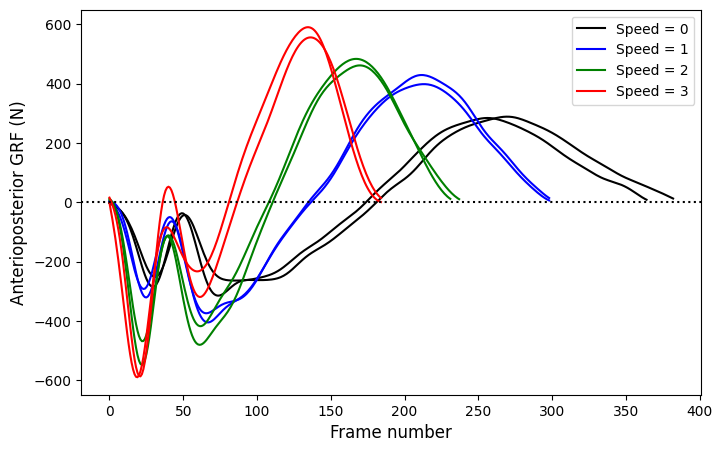

In [2]:
dataset = reg1d.data.Dorn2012()
speed   = dataset.group     # running speed code (0-3)
y       = dataset.y         # object array: 8 observations, 185-383 frames each
print(dataset)

def plot_Dorn2012(y, xlabel='Frame number', ylabel='Anterioposterior GRF (N)', title=None, ax=None):
    ax = plt.axes() if ax is None else ax
    reg1d.plot.plot_curves(y, group=speed, ax=ax, colors=['k','b','g','r'],
                           x=None if xlabel.startswith('Frame') else 'percent',
                           labels=[f'Speed = {i}' for i in range(4)])
    ax.axhline(0, color='k', ls=':')
    ax.set_xlabel(xlabel, size=12)
    ax.set_ylabel(ylabel, size=12)
    if title is not None:
        ax.set_title(title, size=14)
    return ax

plt.figure(figsize=(8,5))
plot_Dorn2012(y)
plt.show()

### Linear registration

The number of frames decreases with speed because stance time decreases. `register_linear`
interpolates each observation to `n` equally spaced points. It accepts a single observation
(as in `nlreg1d`) or a sequence of observations of different lengths.

(8, 101)


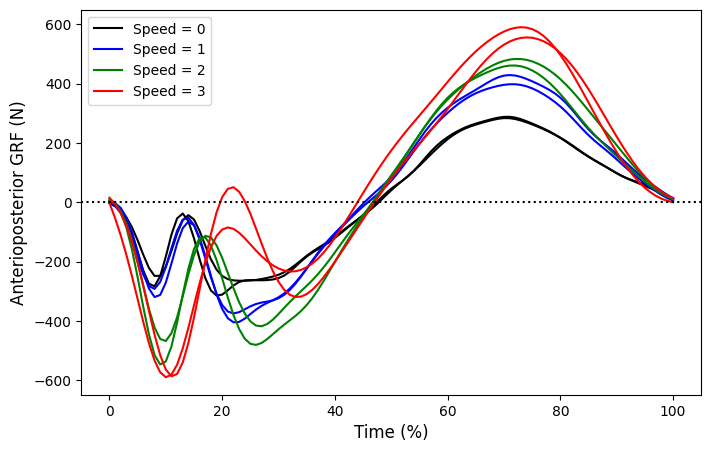

In [3]:
yi = reg1d.register_linear(y, n=101)      # (8,101) array
print(yi.shape)

plt.figure(figsize=(8,5))
plot_Dorn2012(yi, xlabel='Time (%)')
plt.show()

### Nonlinear registration

Local extrema are not aligned in time after linear registration. `register_srsf` aligns the
observations elastically: each observation's square-root slope function (SRSF) is aligned to
an iteratively updated Karcher-mean template by dynamic programming, and the resulting warps are
centred so that their Karcher mean is the identity (the same procedure as `fdasrsf`'s
`srsf_align` with `center=True`).

Like `nlreg1d.register_srsf`, the function can be unpacked into two arrays:

- `yr` : registered data, (J,Q)
- `wf` : optimal warp functions, (J,Q)

but it actually returns a `RegistrationResult` object that also carries the template, the
warps as a `Warp1DList`, and method-specific information.

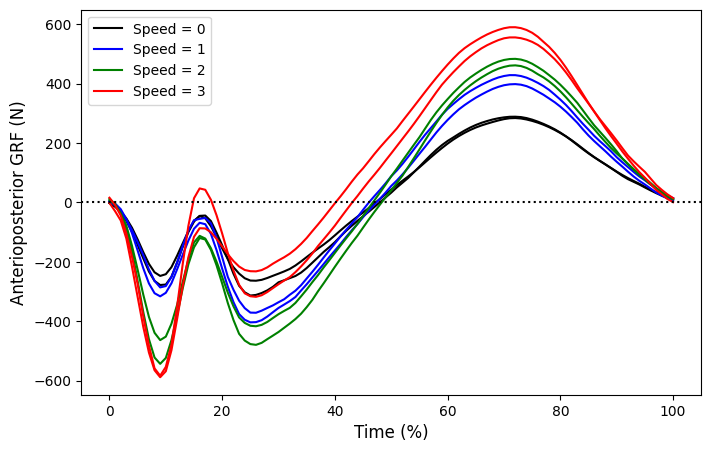

In [4]:
yr, wf = reg1d.register_srsf(yi, max_iter=5)

plt.figure(figsize=(8,5))
plot_Dorn2012(yr, xlabel='Time (%)')
plt.show()

In [5]:
result = reg1d.register_srsf(yi, max_iter=5)
print(result)
print('iterations:', result.info['niter'])
print('SRSF cost per iteration:', result.info['cost'].round(1))

RegistrationResult (srsf)
    y        : (8, 101)
    warps    : (8, 101)
    template : (101,)
    info     : ['niter', 'cost', 'q']

iterations: 5
SRSF cost per iteration: [1003.4  393.5  396.5  390.3  389.5]


### Warp functions and displacement fields

`result.warps` is a `Warp1DList`. Its `displacement_field()` method returns the deviation from
linear time expressed on the original time axis (the quantity plotted in `nlreg1d`).

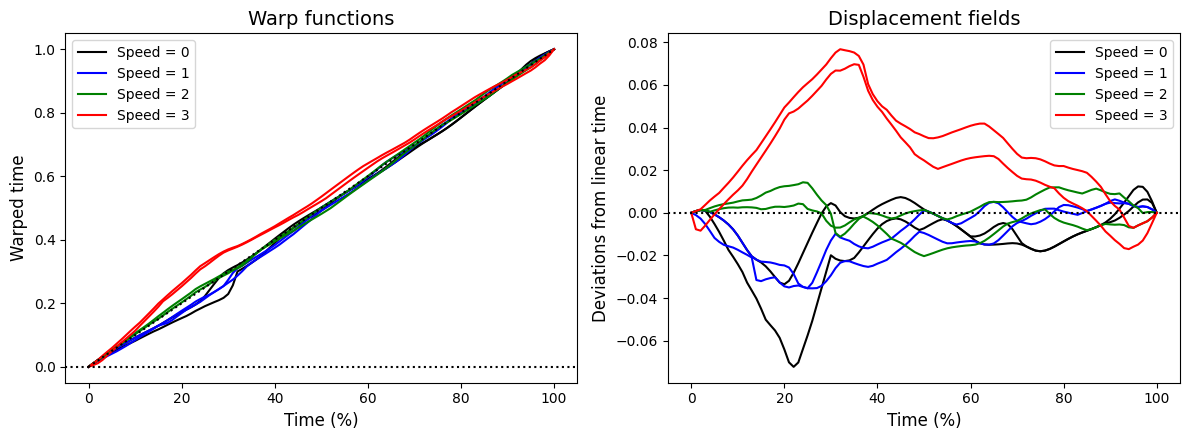

In [6]:
wlist = result.warps                       # Warp1DList
d     = wlist.displacement_field()         # (8,101)

fig,AX = plt.subplots(1, 2, figsize=(12,4.5))
plot_Dorn2012(wf, xlabel='Time (%)', ylabel='Warped time', title='Warp functions', ax=AX[0])
AX[0].plot([0,100],[0,1],'k:')
plot_Dorn2012(d, xlabel='Time (%)', ylabel='Deviations from linear time', title='Displacement fields', ax=AX[1])
plt.tight_layout()
plt.show()

### Three-panel summary

Every `RegistrationResult` has a `plot` method giving a before / after / warps summary.

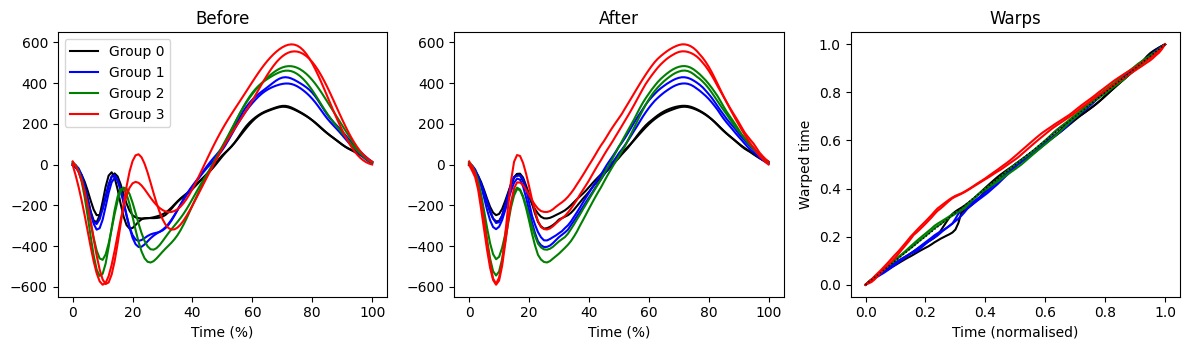

In [7]:
result.plot(group=speed, colors=['k','b','g','r'])
plt.show()

### Agreement with fdasrsf (optional)

If `fdasrsf` happens to be installed, the cell below compares the warps found by `reg1d` with
those found by `fdasrsf.fdawarp.srsf_align` for the same data and settings. `reg1d` is **not**
a dependency-free copy of `fdasrsf` — the dynamic programming grid, the numerical derivative used
for the SRSF and the centring step are all independent implementations — so the two are expected
to agree closely but not exactly. This cell is skipped silently if `fdasrsf` is unavailable.

fdasrsf version: 2.7.2
max |warp difference| per observation: [0.008 0.063 0.012 0.009 0.01  0.008 0.007 0.01 ]


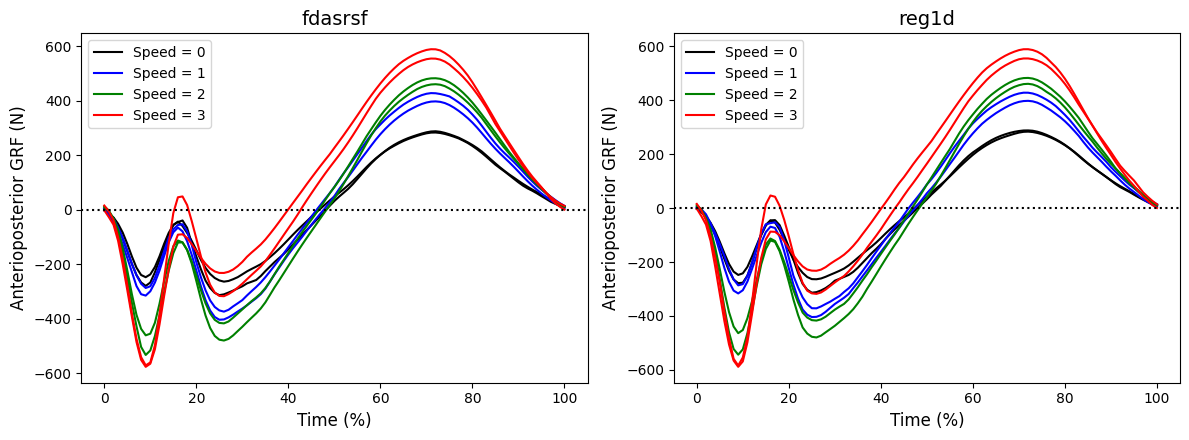

In [8]:
try:
    import fdasrsf, io, contextlib
    t   = np.linspace(0, 1, 101)
    with contextlib.redirect_stdout(io.StringIO()):
        fw = fdasrsf.fdawarp(yi.T, t)
        fw.srsf_align(MaxItr=5)
    wf_fdasrsf = fw.gam.T
    print('fdasrsf version:', fdasrsf.__version__)
    print('max |warp difference| per observation:', np.abs(wf - wf_fdasrsf).max(axis=1).round(3))
    fig,AX = plt.subplots(1, 2, figsize=(12,4.5))
    plot_Dorn2012(fw.fn.T, xlabel='Time (%)', title='fdasrsf', ax=AX[0])
    plot_Dorn2012(yr, xlabel='Time (%)', title='reg1d', ax=AX[1])
    plt.tight_layout()
    plt.show()
except ImportError:
    print('fdasrsf is not installed; comparison skipped')